In [2]:
import pandas as pd

df = pd.read_csv("movies_dataset.csv")

df.head()

,id,title,rating,year,genres,overview,cast,director,poster_url,poster_local
0,5,Four Rooms,5.898,1995,Comedy,It's Ted the Bellhop's first night on the job....,Tim Roth | Jennifer Beals | David Proval | Ion...,Allison Anders | Alexandre Rockwell | Quentin ...,https://image.tmdb.org/t/p/w500/75aHn1NOYXh4M7...,posters\90c62e0d671882e3b4a8070109a9b9b1.jpg
1,11,Star Wars,8.203,1977,"Adventure, Action, Science Fiction",Princess Leia is captured and held hostage by ...,Mark Hamill | Harrison Ford | Carrie Fisher | ...,George Lucas,https://image.tmdb.org/t/p/w500/6FfCtAuVAW8XJj...,posters\0dd0e70356dd519fd0dfcc9780e11f54.jpg
2,12,Finding Nemo,7.818,2003,"Animation, Family, Adventure","Nemo, an adventurous young clownfish, is unexp...",Albert Brooks | Ellen DeGeneres | Alexander Go...,Andrew Stanton,https://image.tmdb.org/t/p/w500/eHuGQ10FUzK1md...,posters\e3671f40bac65417c5d9d63741f366b5.jpg
3,13,Forrest Gump,8.464,1994,"Comedy, Drama, Romance",A man with a low IQ has accomplished great thi...,Tom Hanks | Robin Wright | Gary Sinise | Sally...,Robert Zemeckis,https://image.tmdb.org/t/p/w500/Cw4hIUIAmSYfK9...,posters\4ad431c478cc8213fe514b1b8e9e41f3.jpg
4,14,American Beauty,8.000,1999,Drama,"Lester Burnham, a depressed suburban father in...",Kevin Spacey | Annette Bening | Thora Birch | ...,Sam Mendes,https://image.tmdb.org/t/p/w500/wby9315QzVKdW9...,posters\985897d826bd9901207284642155587f.jpg


In [3]:
import numpy as np
import pandas as pd

# لود الداتا الكاملة
df = pd.read_csv("movies_dataset.csv")
df = df[['title', 'genres', 'overview', 'rating']].dropna().reset_index(drop=True)

# لود الـ LSTM features الكاملة (4096 صف)
lstm_features = np.load("lstm_features_train.npy")   # (4096, 512)

# خد نفس عدد الـ LSTM
n = min(len(lstm_features), len(df))
lstm_features = lstm_features[:n]
df = df.iloc[:n].reset_index(drop=True)

print(f"✅ Using {n} samples")
print(f"   LSTM: {lstm_features.shape}")

✅ Using 4096 samples
   LSTM: (4096, 512)


In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['overview'])
sequences = tokenizer.texts_to_sequences(df['overview'])
text_data = pad_sequences(sequences, maxlen=200)

text_input = Input(shape=(200,))
x = Embedding(5000, 128)(text_input)
x = LSTM(64)(x)
text_model = Model(text_input, x)

text_features = text_model.predict(text_data)
print("Text features:", text_features.shape)

128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step
Text features: (4096, 64)


In [5]:
resnet_features = np.load("resnet_features.npy")

n = min(len(text_features), len(lstm_features), len(resnet_features))

text_f   = text_features[:n]
lstm_f   = lstm_features[:n]
resnet_f = resnet_features[:n]
labels   = df['rating'].values[:n]

combined = np.concatenate([text_f, lstm_f, resnet_f], axis=1)

print(f"✅ n={n}")
print(f"Combined shape: {combined.shape}")
print(f"Labels shape:   {labels.shape}")

✅ n=4096
Combined shape: (4096, 2624)
Labels shape:   (4096,)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined, labels, test_size=0.2, random_state=42
)

final_model = Sequential([
    Dense(512, activation='relu', input_shape=(combined.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(1)
])

final_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
final_model.summary()

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

C:\Users\User\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,344,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,510,401 (5.76 MB)

 Trainable params: 1,509,377 (5.76 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 3.7910 - mae: 1.3515 - val_loss: 5.6070 - val_mae: 2.1762
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 1.2080 - mae: 0.8669 - val_loss: 1.6612 - val_mae: 1.0653
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 1.0975 - mae: 0.8286 - val_loss: 1.0050 - val_mae: 0.7964
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.9927 - mae: 0.7886 - val_loss: 0.9862 - val_mae: 0.7919
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.8883 - mae: 0.7422 - val_loss: 0.8512 - val_mae: 0.7302
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.8749 - mae: 0.7449 - val_loss: 1.0220 - val_mae: 0.8096
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.7850 - mae: 0.7021 - val_loss: 0.8599 - val_mae: 0.7249
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.7477 - mae: 0.6881 - val_loss: 0.9178 - val_mae: 0.7656
Epoch 9/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/

In [8]:
# ── Evaluate ──
loss, mae = final_model.evaluate(X_test, y_test, verbose=0)

print("=" * 40)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE:        {mae:.4f}")
print(f"يعني الموديل بيتوقع الـ rating")
print(f"بفرق ±{mae:.2f} نجمة في المتوسط")
print("=" * 40)

# Save
final_model.save("multimodal_final_model.keras")
np.save("combined_features.npy", combined)
print("✅ Model saved!")

Test Loss (MSE): 0.7953
Test MAE:        0.6999
يعني الموديل بيتوقع الـ rating
بفرق ±0.70 نجمة في المتوسط
✅ Model saved!


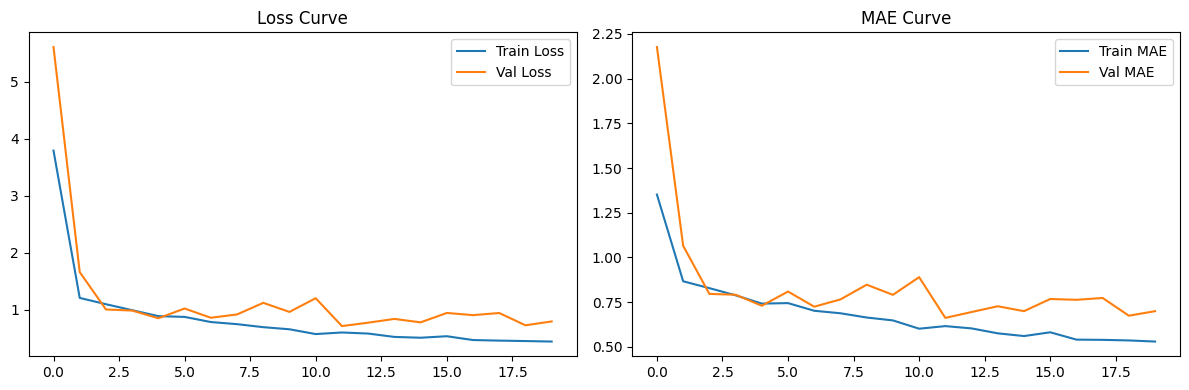

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# ── Recommendation Function ──
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# لود الـ cosine similarity
cosine_sim = np.load("cosine_sim.npy")

with open("cosine_indices.pkl", "rb") as f:
    indices = pickle.load(f)

cosine_df = pd.read_csv("cosine_df.csv")

def recommend(title, top_n=5):
    title_lower = title.lower()
    if title_lower not in indices:
        return f"❌ '{title}' not found"
    
    idx = indices[title_lower]
    sim_scores = sorted(
        list(enumerate(cosine_sim[idx])),
        key=lambda x: x[1], reverse=True
    )[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    results = cosine_df["title"].iloc[movie_indices].values
    
    print(f"\n🎬 Because you watched '{title}', we recommend:")
    for i, movie in enumerate(results, 1):
        print(f"   {i}. {movie}")
    return results

# جرب
recommend("Star Wars")


🎬 Because you watched 'Star Wars', we recommend:
   1. The Empire Strikes Back
   2. Return of the Jedi
   3. Star Wars: The Force Awakens
   4. Star Wars: The Last Jedi
   5. Star Wars: Episode III - Revenge of the Sith


array(['The Empire Strikes Back', 'Return of the Jedi',
       'Star Wars: The Force Awakens', 'Star Wars: The Last Jedi',
       'Star Wars: Episode III - Revenge of the Sith'], dtype=object)